In [ ]:
import yaml
import os

In [ ]:
dataset_path = '/content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO'

data = {
    'path'  : dataset_path,
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 1,
    'names' : ['License Plate']
}


In [ ]:
yaml_path = os.path.join(dataset_path, 'data.yaml')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("data.yaml created!\n")
print("Contents:")
with open(yaml_path, 'r') as f:
    print(f.read())

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00


In [ ]:
# Train YOLOv8 on License Plate Dataset

from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

In [ ]:
# Train
results = model.train(
    data    = '/content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO/data.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = 'license_plate_detector',
    project = '/content/drive/MyDrive/easyPark_GraduationProject/runs',
    device  = 0,
    patience= 10,
    save    = True,
    plots   = True,
)

print(f"Results saved to: {results.save_dir}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_detector, nbs=64, nms=False, opset=None, optimize=False, optim

In [ ]:
# Evaluate the Model

from ultralytics import YOLO

# Load the best trained model weights
model = YOLO('/content/drive/MyDrive/easyPark_GraduationProject/runs/license_plate_detector/weights/best.pt')

In [4]:
# Run evaluation on the test set
metrics = model.val(
    data   = '/content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO/data.yaml',
    split  = 'test',
    device = 0,
    plots  = True,
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 65.1±144.4 ms, read: 0.2±0.1 MB/s, size: 110.2 KB)
val: Scanning /content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO/labels/test... 204 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 204/204 2.4it/s 1:23
val: New cache created: /content/drive/MyDrive/easyPark_GraduationProject/EALPR_YOLO/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1it/s 6.2s
                   all        204        211      0.995      0.991      0.995      0.914
Speed: 3.8ms preprocess, 10.9ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print("\nEvaluation Results:")
print(f"  mAP@50       : {metrics.box.map50:.4f}")
print(f"  mAP@50-95    : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")


📊 Evaluation Results:
  mAP@50       : 0.9950
  mAP@50-95    : 0.9141
  Precision    : 0.9950
  Recall       : 0.9905


In [ ]:
# Run Inference on Custom Images

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Load best trained model
model = YOLO('/content/drive/MyDrive/easyPark_GraduationProject/runs/license_plate_detector/weights/best.pt')

# ── Point to your custom folder ───────────────────────────────────────────────
custom_images_path = '/content/drive/MyDrive/easyPark_GraduationProject/test_custom'

In [ ]:
# Get all images from the folder
all_images = [f for f in os.listdir(custom_images_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Found {len(all_images)} images to test\n")

📷 Found 9 images to test



/tmp/ipykernel_452/1886967142.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


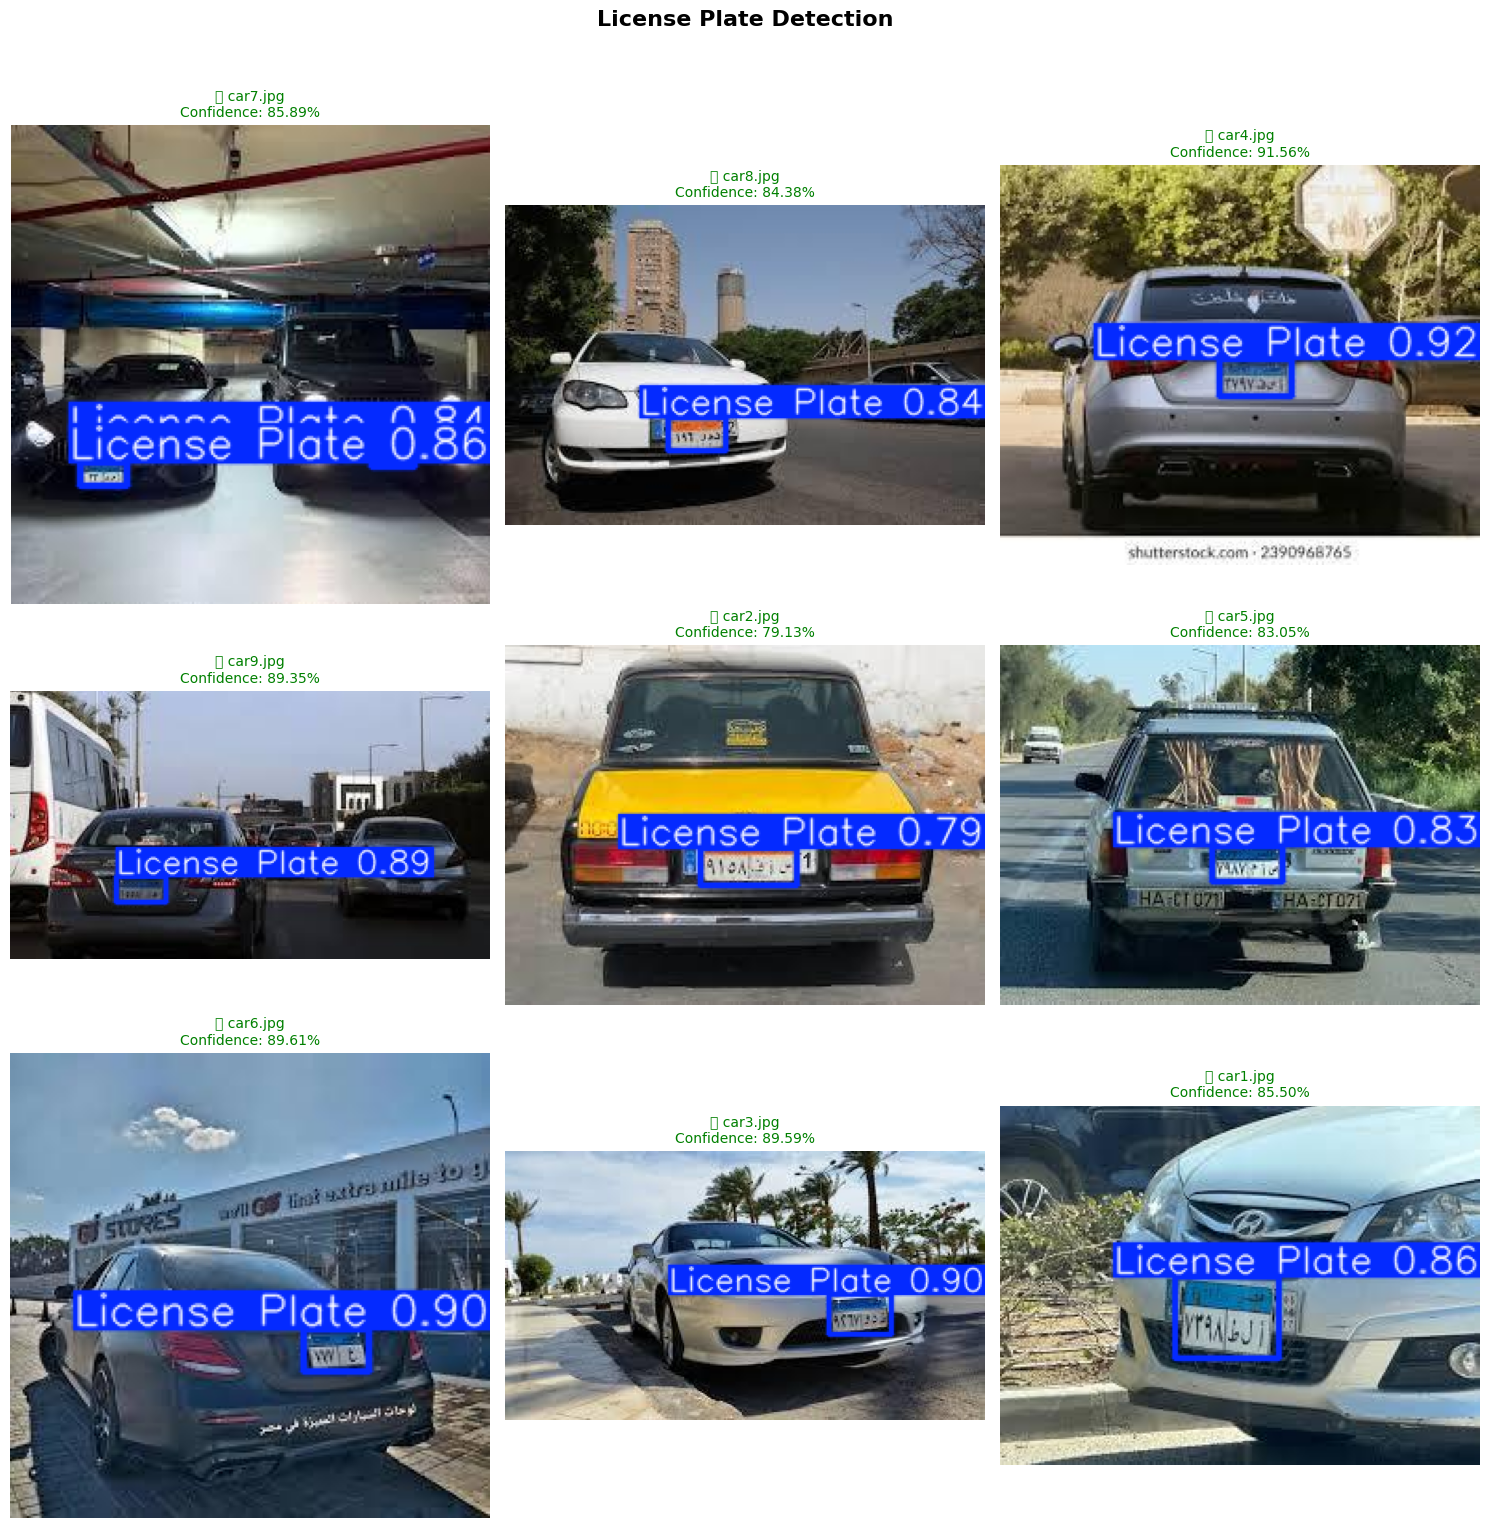

In [ ]:
# Run inference + display
cols = 3
rows = -(-len(all_images) // cols)  # ceiling division
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() if len(all_images) > 1 else [axes]

for idx, img_file in enumerate(all_images):
    img_path = os.path.join(custom_images_path, img_file)

    # Run prediction
    results = model.predict(
        source  = img_path,
        device  = 0,
        conf    = 0.5,
        save    = False,
        verbose = False
    )

    # Get annotated frame
    annotated     = results[0].plot()
    annotated_rgb = annotated[:, :, ::-1]  # BGR -> RGB

    # Display
    axes[idx].imshow(annotated_rgb)
    axes[idx].axis('off')

    # Title with result
    if results[0].boxes:
        conf  = results[0].boxes.conf[0].item()
        axes[idx].set_title(f"{img_file}\nConfidence: {conf:.2%}",
                            fontsize=10, color='green')
    else:
        axes[idx].set_title(f"{img_file}\nNo plate detected",
                            fontsize=10, color='red')

# Hide any unused subplot slots
for i in range(len(all_images), len(axes)):
    axes[i].axis('off')

plt.suptitle("License Plate Detection", fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()